In [1]:
%load_ext autoreload
%autoreload 2
%reset -f

In [2]:
from locallib.picarrodb import *
from locallib.query import *
from data_extractor import ExtractionSpec, extract_multiple_data
from dotenv import load_dotenv
from apps_dal_dynamo.dynamodal import DynamoDalBase

import datetime
import time
import os

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/geopandas/_compat.py:154: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  set_use_pygeos()


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully
EU1_PROD_Conn created successfully
EU2_PROD_Conn created successfully


In [3]:
import boto3
import dotenv
import io
import pandas as pd 
import os
import time

from athena_query import run_athena_query

dotenv.load_dotenv()


True

In [4]:
#Athena setup
# Get AWS setup
AWS_ATHENA_US_PROFILE = os.getenv('AWS_ATHENA_US_PROFILE')
AWS_ATHENA_DYNAMOEXPORTS_WG = os.getenv('AWS_ATHENA_DYNAMOEXPORTS_WG')
AWS_ATHENA_DYNAMOEXPORTS_DB=os.getenv('AWS_ATHENA_DYNAMOEXPORTS_DB')
AWS_ATHENA_DYNAMOEXPORTS_REGION=os.getenv('AWS_ATHENA_DYNAMOEXPORTS_REGION')
AWS_ATHENA_HANDHELD_WG = os.getenv('AWS_ATHENA_HANDHELD_WG')
AWS_ATHENA_HANDHELD_DB = os.getenv('AWS_ATHENA_HANDHELD_DB')
AWS_ATHENA_HANDHELD_REGION = os.getenv('AWS_ATHENA_HANDHELD_REGION')
for var in [
    AWS_ATHENA_US_PROFILE,
    AWS_ATHENA_DYNAMOEXPORTS_WG,
    AWS_ATHENA_DYNAMOEXPORTS_DB,
    AWS_ATHENA_DYNAMOEXPORTS_REGION,
    AWS_ATHENA_HANDHELD_WG,
    AWS_ATHENA_HANDHELD_DB,
    AWS_ATHENA_HANDHELD_REGION,
]:
    assert var is not None, f"Variable {var} is not set"
available = boto3.Session().available_profiles
print("AWS profiles on this machine:", available or "(none)")
print("Expected profile:", AWS_ATHENA_US_PROFILE)

if AWS_ATHENA_US_PROFILE not in available:
    raise RuntimeError(
        f"AWS profile '{AWS_ATHENA_US_PROFILE}' not found.\n"
        "Run: bash setup_athena_aws.sh\n"
        "You need your org's AWS SSO start URL (AWS access portal URL)."
    )
print("Profile found — OK")

session_dynamoexports = boto3.Session(
  profile_name=AWS_ATHENA_US_PROFILE, 
  region_name=AWS_ATHENA_DYNAMOEXPORTS_REGION
)
athena_dynamoexports = session_dynamoexports.client('athena')
s3_dynamoexports = session_dynamoexports.client('s3')

AWS profiles on this machine: ['default', 'Data-Analytics-Athena-User-580855453261']
Expected profile: Data-Analytics-Athena-User-580855453261
Profile found — OK


In [ ]:
# Set analyzer_id and range of months to fetch
analyzer_id = '3A6DC973-6E18-BC7B-DE8E-39FDBD1F7731'
analyzer_id_lower = analyzer_id.lower()
analyzer_id_upper = analyzer_id.upper()
start_date = "2024-06-01"
end_date = "2025-07-01"
case_id = 'US_03'

In [6]:
q = f"""SELECT S.Id as SurveyId, 
        S.StartEpoch as StartEpoch, 
        S.EndEpoch as EndEpoch, 
        (SELECT Description FROM SurveyorUnit SU WHERE SU.Id = S.SurveyorUnitId) AS SurveyorUnit,
        (SELECT COUNT(P.Id) FROM Peak P WHERE P.SurveyId = S.Id) as PeakCount,
        MONTH(S.StartDateTime) as Month, 
        YEAR(S.StartDateTime) as Year 
        FROM Survey S 
        WHERE S.AnalyzerId = '{analyzer_id_lower}' 
        AND S.StartDateTime >= '{start_date}'
        AND S.StartDateTime <= '{end_date}'"""
surveys = Query(q).execute(US_Conn)

In [7]:
from datetime import datetime, timedelta

def get_year_month_pairs(start_str, end_str):
    start = datetime.strptime(start_str, "%Y-%m-%d")
    end = datetime.strptime(end_str, "%Y-%m-%d")
    pairs = []
    current = datetime(start.year, start.month, 1)
    # go up to but not including the end month (if end is always 1st of month)
    while current < end:
        pairs.append((current.year, current.month))
        # move to next month
        if current.month == 12:
            current = datetime(current.year + 1, 1, 1)
        else:
            current = datetime(current.year, current.month + 1, 1)
    return pairs

year_month_pairs = get_year_month_pairs(start_date, end_date)
print("Year,Month pairs from start_date to end_date:", year_month_pairs)

Year,Month pairs from start_date to end_date: [(2024, 7), (2024, 8), (2024, 9), (2024, 10), (2024, 11), (2024, 12), (2025, 1), (2025, 2), (2025, 3), (2025, 4), (2025, 5)]


In [8]:
results = []
for year_month in year_month_pairs:
    year = year_month[0]
    month = year_month[1]
    print('Getting Athena data for ', year, month)
    query_dynamoexports = f"""
    SELECT *
    FROM surveyorproduction_measurement_parquet
    WHERE analyzer_id = '{analyzer_id_lower}'
    AND YEAR = {year}
    AND MONTH = {month}
    """
    out_loc_dynamoexports = run_athena_query(
        query=query_dynamoexports, 
        client=athena_dynamoexports,
        db=AWS_ATHENA_DYNAMOEXPORTS_DB, 
        wg=AWS_ATHENA_DYNAMOEXPORTS_WG
    )
    if out_loc_dynamoexports is None:
        print(f"Athena query failed")
        continue
    bucket_dynamoexports, _, key_dynamoexports = out_loc_dynamoexports[len("s3://"):].partition("/")
    obj_dynamoexports = s3_dynamoexports.get_object(Bucket=bucket_dynamoexports, Key=key_dynamoexports)
    # Read CSV into DataFrame and append
    athena_month = pd.read_csv(io.BytesIO(obj_dynamoexports['Body'].read()))
    surveys_month = surveys[surveys['Month'] == month]
    print('Number of surveys in month', month, len(surveys_month))
    for idx, survey in surveys_month.iterrows():
        print('Processing survey', survey['SurveyId'])
        data_survey = athena_month[(athena_month['epoch_time'] >= survey['StartEpoch'])&(athena_month['epoch_time'] <= survey['EndEpoch'])]
        averageFlowRate = data_survey['mobile_flow_rate'].mean()
        surveyId = survey['SurveyId']
        startEpoch = survey['StartEpoch']
        endEpoch = survey['EndEpoch']
        surveyorUnit = survey['SurveyorUnit']
        peakCount = survey['PeakCount']
        rawDurationMinutes = (endEpoch - startEpoch) / 60
        peakMinutes = peakCount / rawDurationMinutes
   
        results.append({'SurveyId': surveyId, 'AverageFlowRate': averageFlowRate, 'StartEpoch': startEpoch, 'EndEpoch': endEpoch, 'SurveyorUnit': surveyorUnit, 'PeakCount': peakCount, 'RawDurationMinutes': rawDurationMinutes, 'PeakMinutes': peakMinutes})

# Create a dataframe from the results list
df = pd.DataFrame(results)


Getting Athena data for  2024 7
Number of surveys in month 7 134
Processing survey 14B30994-0C67-9A12-FB05-3A141D21ED44
Processing survey 24E1AA2A-4F59-B566-1D3D-3A141D0571FA
Processing survey 1DC7B398-ACFC-66DE-A3DC-3A1418E35E74
Processing survey 62820596-DB27-8217-695D-3A1418D32822
Processing survey AFF4E5DB-119A-8B98-1AA5-3A1418B9209E
Processing survey 3F920945-09B5-7C8D-82B8-3A1418AE7899
Processing survey BF49C6A2-B36D-4E5E-5635-3A1418948F90
Processing survey 7CFD3F0C-D635-3362-63C1-3A1418712ADF
Processing survey 57472A68-D024-DC8B-3A0D-3A14183F4506
Processing survey 13D7E366-8BF2-F530-E0B8-3A1418110965
Processing survey A351E2FE-6515-00F4-430A-3A1413BF1C62
Processing survey E0F2237F-3366-223D-EA75-3A14137EC027
Processing survey 2801FDE4-67D9-EE1A-A9CA-3A141355E30B
Processing survey E130C9A4-79D0-230D-27C6-3A14132E5E3D
Processing survey 2F5F7AD2-BB01-6B43-A9A4-3A14131CB386
Processing survey D4AF62F0-78C8-E795-F417-3A1413062369
Processing survey B7F6B19A-F16B-0F2A-30EE-3A1412E1E2C7


In [9]:
df_with_dates = df.copy()
df_with_dates['StartDateTime'] = pd.to_datetime(df_with_dates['StartEpoch'], unit='s')
df_with_dates['EndDateTime'] = pd.to_datetime(df_with_dates['EndEpoch'], unit='s')
df_with_dates['CaseId'] = case_id
df_sorted = df_with_dates.sort_values('StartEpoch')
df_sorted.to_parquet(f"{case_id}.parquet")


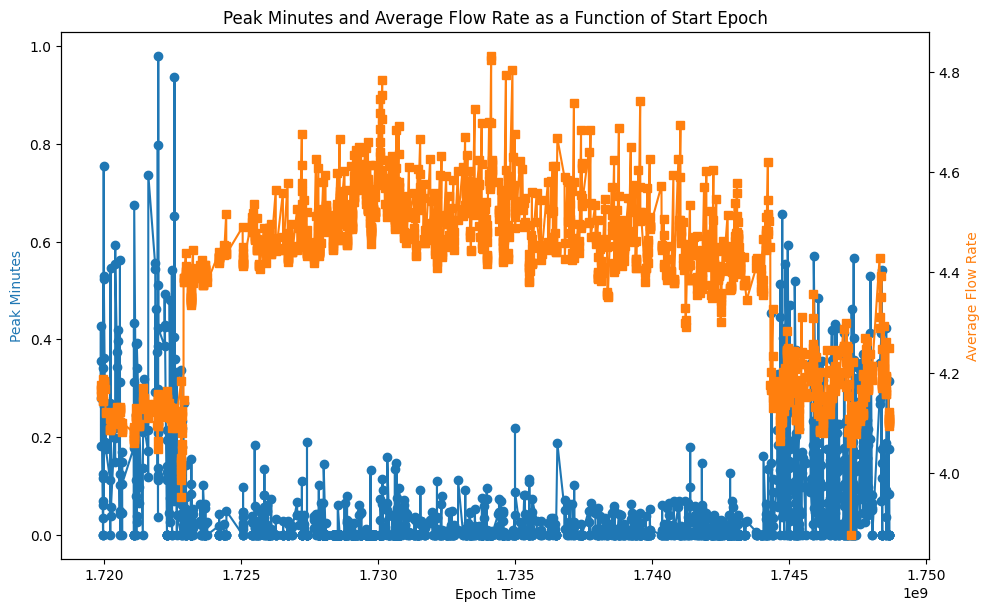

In [10]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Epoch Time')
ax1.set_ylabel('Peak Minutes', color=color1)
ax1.plot(df_sorted['StartEpoch'], df_sorted['PeakMinutes'], color=color1, marker='o', label='Peak Minutes')

ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Average Flow Rate', color=color2)
ax2.plot(df_sorted['StartEpoch'], df_sorted['AverageFlowRate'], color=color2, marker='s', label='Average Flow Rate')

fig.tight_layout()
plt.title("Peak Minutes and Average Flow Rate as a Function of Start Epoch")
plt.show()